1. Change the text prompt to “a futuristic city at sunrise” in the image generation with the diffusers library code. Rerun the code to see the generated image.

In [1]:
!pip install diffusers

In [2]:
!pip install transformers==4.55.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 101.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 111.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/1.72G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

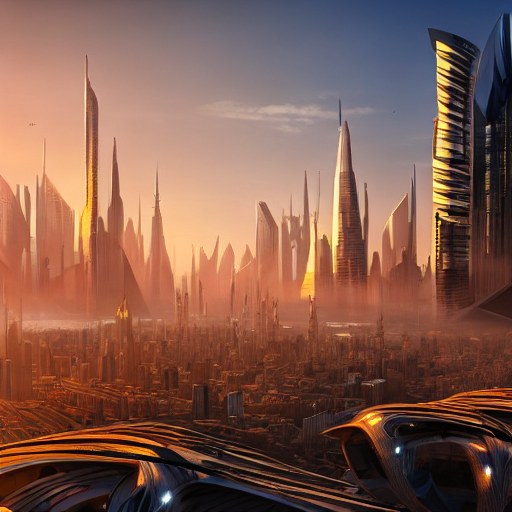

In [3]:
#2min
import torch
from diffusers import StableDiffusionPipeline

torch.manual_seed(42)
prompt="a futuristic city at sunrise"#aici---------------------------------------------------------------------------------
pipe = StableDiffusionPipeline.from_pretrained( #Uses the StableDiffusionPipeline package in the diffusers library
    "CompVis/stable-diffusion-v1-4", #Selects the version of the Stable Diffusion model
    variant="fp16", #Chooses the half-precision floating-point format
    torch_dtype=torch.float16).to("cuda")
image = pipe(prompt).images[0]
image

2. Define prompt3 and prompt4 as “a leopard” and “a lioness”, respectively. Then tokenize the two prompts, and convert them to text embeddings, text_embedding3 and text_embedding4.

  0%|          | 0/50 [00:00<?, ?it/s]

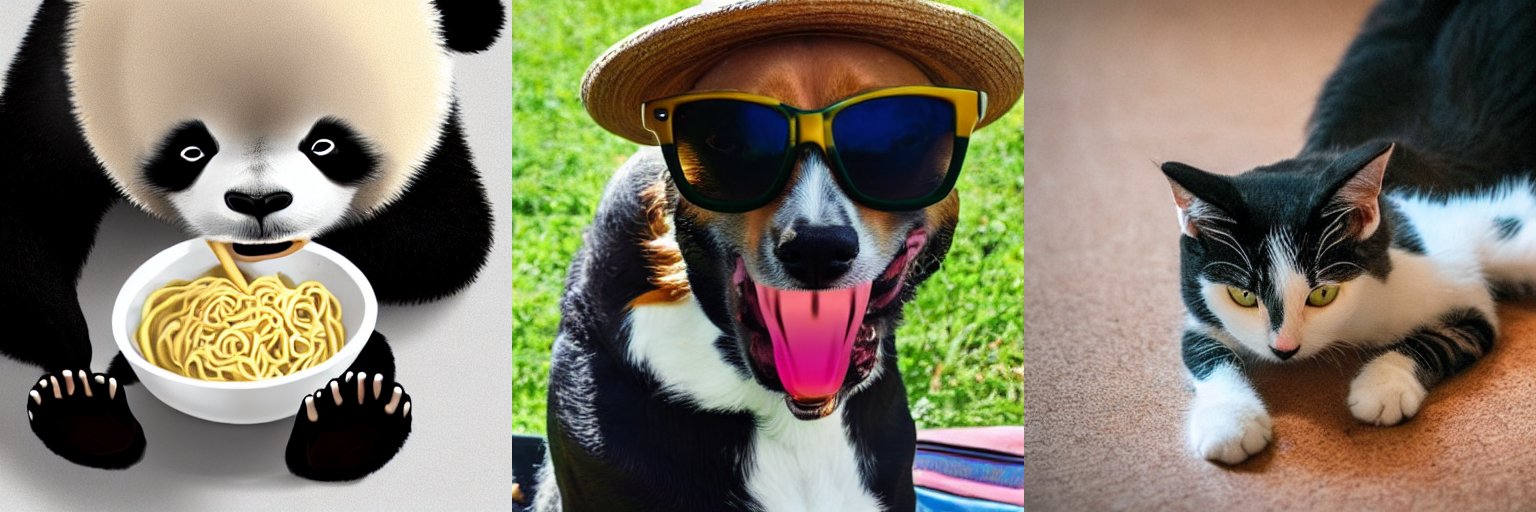

In [4]:
from PIL import Image

torch.manual_seed(0)
prompts = ["a panda eating a bowl of noodles",
    "a dog with sunglasses and a straw hat",
    "a cat stretching on the floor"] #Provides a list of three different text prompts
images = pipe(prompts).images
grid = Image.new('RGB', size=(3*images[0].size[0],
                  images[0].size[1]))
for i, img in enumerate(images): #Places the three output images in a 1 × 3 grid
    grid.paste(img, box=(i*images[0].size[0], 0))
grid

  0%|          | 0/50 [00:00<?, ?it/s]

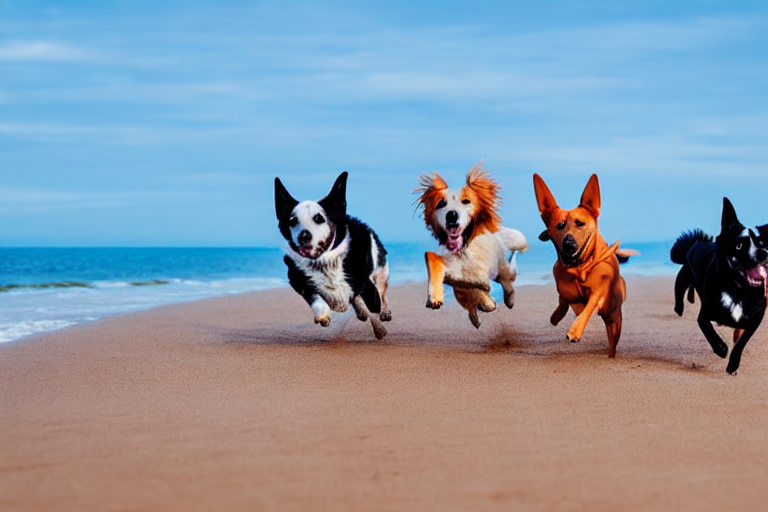

In [5]:
torch.manual_seed(42)
prompt = "dogs running on a sandy beach under blue sky"
images = pipe(prompt,width=768,height=512, #Sets the image resolution to 768 × 512
             guidance_scale=12).images #Changes the CFG parameter to 12
images[0]

In [6]:
class Config:
    height = 512    #Height of the generated image
    width = 512    #Width of the generated image
    guidance_scale = 7.5    #CFG-guidance parameter
    num_inference_steps=50    #Number of inference steps
config=Config()

prompts3 = ["a leopard"] #Prompt 1
prompts4 = ["a lioness"] #Prompt 2

In [7]:
from transformers import CLIPTextModel, CLIPTokenizer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = CLIPTokenizer.from_pretrained(
    "openai/clip-vit-large-patch14") #Imports the pretrained CLIP tokenizer
text_encoder = CLIPTextModel.from_pretrained(
    "openai/clip-vit-large-patch14").to(device) #Imports the pretrained CLIP text encoder

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

In [9]:
tokens1=tokenizer(prompts3,padding="max_length",
              max_length=tokenizer.model_max_length,
              truncation=True, return_tensors="pt")
tokens2=tokenizer(prompts4,padding="max_length",
              max_length=tokenizer.model_max_length,
              truncation=True, return_tensors="pt") #Converts the two prompts into sequences of indices
with torch.no_grad():
    text_embeddings3=text_encoder(
        tokens1.input_ids.to(device))[0]
    text_embeddings4=text_encoder(
        tokens2.input_ids.to(device))[0] #Generates two text embeddings
print("text embedding 1 shape:", text_embeddings3.shape)
print("text embedding 2 shape:", text_embeddings3.shape)

text embedding 1 shape: torch.Size([1, 77, 768])
text embedding 2 shape: torch.Size([1, 77, 768])


3. Apply the gen_latents() function on the two text embeddings text_embedding3 and text_embedding4, which were generated earlier. Set the seed value to 8. Name the latent images latents3 and latents4.

In [10]:
unconditional_prompt = [""] #The unconditional prompt is an empty string.
uncond_input = tokenizer(unconditional_prompt,
             padding="max_length",
             max_length=tokenizer.model_max_length,
             return_tensors="pt") #Tokenizes the unconditional prompt
with torch.no_grad():
    uncond_embeds=text_encoder(
        uncond_input.input_ids.to(device))[0] #Converts the unconditional prompt into a text embedding

In [11]:
#4min
from diffusers import LMSDiscreteScheduler
from diffusers import UNet2DConditionModel

scheduler = LMSDiscreteScheduler(beta_start=0.00085,
                     beta_end=0.012,
                     beta_schedule="scaled_linear",
                     num_train_timesteps=1000) #Creates the K-LMS scheduler

unet = UNet2DConditionModel.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="unet")
unet = unet.to(device) #Creates the pretrained denoising U-Net

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

In [12]:
from tqdm import tqdm

def gen_latents(text_embeddings, seed):
    torch.manual_seed(seed)
    scheduler.set_timesteps(config.num_inference_steps)
    latents = torch.randn((1, unet.config.in_channels, #The starting image consists of pure random noise.
           config.height // 8, config.width // 8)).to(device)
    latents = latents * scheduler.init_noise_sigma
    text_embeddings=torch.cat([uncond_embeds, text_embeddings])
    with torch.autocast(device):
        for i, t in tqdm(enumerate(scheduler.timesteps)): #Iteratively denoises the image for 50 inference steps
            latent_model_input = torch.cat([latents] * 2)
            sigma = scheduler.sigmas[i]
            latent_model_input = scheduler.scale_model_input(
                latent_model_input, t)
            with torch.no_grad():
                noise_pred = unet(latent_model_input, t,
                  encoder_hidden_states=text_embeddings).sample
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred=noise_pred_uncond+config.guidance_scale*(
                noise_pred_text - noise_pred_uncond)
            latents = scheduler.step(noise_pred,
                                     t, latents).prev_sample
    return 1 / 0.18215 * latents #Divides the output by 0.18215 to undo a previous scaling during training

In [13]:
latents3=gen_latents(text_embeddings3,seed=8)#AICI--------------------------------------------------------
latents4=gen_latents(text_embeddings4,seed=8)#AICI--------------------------------------------------------
print(f"latent image size is {latents3[0].shape}")#AICI--------------------------------------------------------

50it [00:07,  6.49it/s]
50it [00:07,  6.45it/s]

latent image size is torch.Size([4, 64, 64])


4. Convert the two latent images, latents3 and latents4, into high-resolution images. Name them images3 and images4, respectively.

In [14]:
from diffusers import AutoencoderKL

vae = AutoencoderKL.from_pretrained(
      "CompVis/stable-diffusion-v1-4",
      subfolder="vae").to(device)

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

In [15]:
with torch.no_grad():
    images3 = vae.decode(latents3).sample
    images4 = vae.decode(latents4).sample
print(f"final image size is {images4[0].shape}")

final image size is torch.Size([3, 512, 512])


5. Plot the two latent images, latents3 and latents4, and the two outputs, images3 and images4, in a 1×4 grid. Label the four images accordingly.

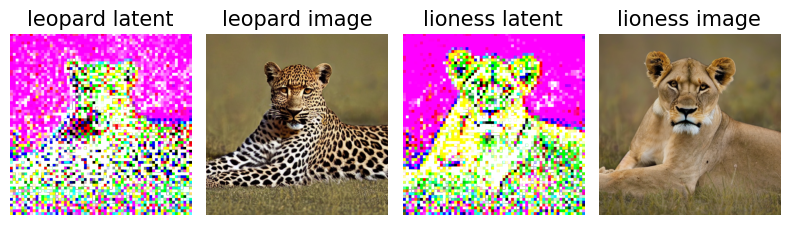

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def latent_to_display_image(latent, upsample_factor=8):
    """
    Processes a latent tensor for display:
    - Permutes to (H, W, C)
    - Clips to [-1, 1]
    - Upsamples by repeating pixels
    - Rescales from [-1, 1] to [0, 1]
    - Converts to numpy array
    """
    # Permute, clip to [-1,1], and detach
    image = latent[0].permute(1, 2, 0).detach().cpu()
    image = torch.clamp(image, -1, 1)
    # Upsample by repeating pixels
    image = image.repeat_interleave(upsample_factor,
        dim=0).repeat_interleave(upsample_factor, dim=1)
    # Rescale to [0,1]
    image = (image + 1) / 2
    return image.numpy() #Changes the latent image to a displayable format

def output_to_display_image(output):
    """
    Processes a final output image tensor for display:
    - Permutes to (H, W, C)
    - Rescales from [-1, 1] to [0, 1] if needed
    - Clips to [0, 1]
    - Converts to numpy array
    """
    image = output[0].permute(1, 2, 0).detach().cpu()
    image = (image + 1) / 2
    image = torch.clamp(image, 0, 1)
    return image.numpy() #Changes the final output image to a displayable format

# Prepare images for display
display_imgs = [
    latent_to_display_image(latents3),
    output_to_display_image(images3),
    latent_to_display_image(latents4),
    output_to_display_image(images4)
]

captions = [
    "leopard latent",
    "leopard image",
    "lioness latent",
    "lioness image" #Creates four captions
]

plt.figure(figsize=(8, 5), dpi=100)
for i in range(4): #Plots the four images in a 1 × 4 grid
    plt.subplot(1, 4, i + 1)
    plt.imshow(display_imgs[i])
    plt.title(captions[i], fontsize=15)
    plt.axis('off')
plt.tight_layout()
plt.show()



6. Let the variable weight take five values, 0.9, 0.7, 0.5, 0.3, and 0.1. Create five interpolated text embeddings of text_embeddings3 and text_embeddings4 based on these weights. Feed the interpolated text embeddings to the gen_latents() function to generate five latent images. Convert the five latent images to high-resolution ones using the VAE decoder. Plot the five high-resolution images in a 1×5 grid, and label them accordingly.

In [20]:
images=[]
for weight in [0.9, 0.7, 0.5, 0.3, 0.1]: #Chooses five different values of weights
    text_embeddings = weight * text_embeddings3 +\
        (1-weight) * text_embeddings4 #Creates an interpolated text embedding based on the weight
    latents=gen_latents(text_embeddings,seed=5) #Generates a latent image based on the text embedding
    with torch.no_grad():
        images.append(vae.decode(latents).sample) #Converts the latent image into a high-resolution image

50it [00:07,  6.35it/s]
50it [00:07,  6.26it/s]
50it [00:08,  6.12it/s]
50it [00:08,  5.89it/s]
50it [00:08,  5.68it/s]


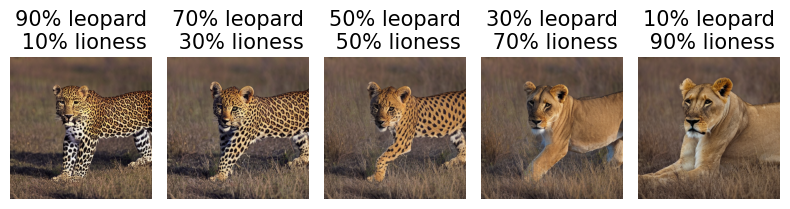

In [22]:
plt.figure(figsize=(8,5),dpi=100)
for i in range(5): #Plots the five images in a 1 × 5 grid
    plt.subplot(1,5,i+1)
    img=torch.clip(images[i][0].detach().cpu(
        ).permute(1,2,0)/2+0.5,0,1)
    plt.imshow(img)
    plt.title(f"{90-20*i}% leopard\n {10+20*i}% lioness",
              fontsize=15) #Labels the images
    plt.axis('off')
plt.tight_layout()
plt.show()